# HOG and HSV classical baselines

This notebook trains three linear-SVM baselines: HOG shape features, HSV colour histograms, and their concatenation. It uses the same manifest-backed train, validation and held-out test splits as the ResNet experiments. Validation macro-F1 selects `C`; the test set is evaluated only after model selection.

## Runtime setup

Configure `INAT_DATA_ARCHIVE` in the project `.env` file and run `inat-prepare` once before opening this notebook. This classical HOG/HSV + SGD pipeline runs on the CPU and uses the same configured local dataset as the deep models.

In [ ]:
from pathlib import Path
import sys

candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (path.resolve() for path in candidates if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Open this notebook from a local project checkout.")
sys.path.insert(0, str(REPO_ROOT / "src"))

from inat_project.paths import get_project_paths, require_dataset

PATHS = get_project_paths(REPO_ROOT)
DATA_ROOT = require_dataset(PATHS)
METADATA_ROOT = PATHS.metadata_root
CHECKPOINT_ROOT = PATHS.checkpoint_root
print(f"Repository:  {REPO_ROOT}")
print(f"Data:        {DATA_ROOT}")
print(f"Checkpoints: {CHECKPOINT_ROOT}")


In [ ]:
RESULT_ROOT = PATHS.results_root / "classical"
CHECKPOINT_ROOT = PATHS.checkpoint_root / "classical"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Data: {DATA_ROOT}")
print(f"Results: {RESULT_ROOT}")


In [11]:
import json
import platform
import time
from collections.abc import Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import skimage
import torch
from matplotlib.colors import rgb_to_hsv
from IPython.display import Image as NotebookImage, Markdown, display
from skimage.feature import hog
from sklearn.metrics import accuracy_score, f1_score, hinge_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from tqdm.auto import tqdm

from inat_project.config import load_config
from inat_project.data import (
    build_classical_transform,
    create_dataloaders,
    validate_manifests,
)
from inat_project.evaluation import (
    confusion_data,
    most_confused_pairs,
    save_metrics,
    summarise_predictions,
)
from inat_project.plots import plot_confused_pairs, plot_confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")
DISPLAY_NAMES = {"hog": "HOG", "hsv": "HSV", "hog_hsv": "HOG + HSV"}

## Configuration and shared data loaders

The loaders reuse the canonical manifests and labels. Unlike the deep models, HOG/HSV receives deterministic 128×128 uint8 pixels: random augmentation and ImageNet normalisation would distort the handcrafted descriptors.

In [ ]:
config = load_config(REPO_ROOT / "configs/hog_hsv.yaml")
METADATA_ROOT = PATHS.metadata_root
split_counts = validate_manifests(
    METADATA_ROOT, expected_classes=config["data"]["num_classes"]
)
with (METADATA_ROOT / "class_to_idx.json").open(encoding="utf-8") as handle:
    class_to_idx = json.load(handle)
idx_to_class = {index: name for name, index in class_to_idx.items()}
display(config)
display(split_counts.describe().loc[["min", "max"]])

In [13]:
data_config = config["data"]
pixel_transform = build_classical_transform(data_config["image_size"])
loaders = create_dataloaders(
    DATA_ROOT,
    METADATA_ROOT,
    batch_size=data_config["batch_size"],
    image_size=data_config["image_size"],
    num_workers=data_config["num_workers"],
    seed=config["seed"],
    train_transform=pixel_transform,
    evaluation_transform=pixel_transform,
    return_paths=True,
)
for split_name, loader in loaders.items():
    print(f"{split_name:>10}: {len(loader.dataset):,} images, {len(loader):,} batches")

images, labels, paths = next(iter(loaders["train"]))
print(f"Batch shape: {tuple(images.shape)}, dtype: {images.dtype}")

     train: 20,000 images, 313 batches
validation: 5,000 images, 79 batches
      test: 5,000 images, 79 batches
Batch shape: (64, 3, 128, 128), dtype: torch.uint8


## Extract HOG and HSV features

This keeps the original author's structure: one extractor per representation, followed by `format_model_data`. The only important change is that images now come from the project's manifest-backed `DataLoader` rather than opening paths from a CSV manually. HOG describes shape and local edges; HSV histograms describe colour.

In [14]:
def _rgb_array(image: torch.Tensor | np.ndarray) -> np.ndarray:
    """Convert a CHW tensor into a float HWC RGB image."""
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
    image = np.asarray(image)
    if image.ndim != 3:
        raise ValueError(f"Expected a 3D image, received {image.shape}.")
    if image.shape[0] == 3:
        image = np.moveaxis(image, 0, -1)
    if image.shape[-1] != 3:
        raise ValueError(f"Expected RGB channels, received {image.shape}.")
    image = image.astype(np.float32, copy=False)
    if image.max(initial=0.0) > 1.0:
        image = image / 255.0
    return np.clip(image, 0.0, 1.0)


def extract_hog(image: torch.Tensor | np.ndarray) -> np.ndarray:
    """Original HOG idea: grayscale gradients, 8x8 cells and 2x2 blocks."""
    rgb = _rgb_array(image)
    grayscale = 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]
    return hog(
        grayscale,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    ).astype(np.float32)


def extract_hsv(image: torch.Tensor | np.ndarray) -> np.ndarray:
    """Original HSV idea: concatenate normalised H, S and V histograms."""
    hsv = rgb_to_hsv(_rgb_array(image))
    hue, _ = np.histogram(hsv[..., 0], bins=32, range=(0.0, 1.0))
    saturation, _ = np.histogram(hsv[..., 1], bins=16, range=(0.0, 1.0))
    value, _ = np.histogram(hsv[..., 2], bins=16, range=(0.0, 1.0))
    features = np.concatenate([hue, saturation, value]).astype(np.float32)
    return features / (features.sum() + 1e-8)


def extract_hog_hsv(image: torch.Tensor | np.ndarray) -> np.ndarray:
    return np.concatenate([extract_hog(image), extract_hsv(image)])


def format_model_data(loader, extractor: Callable, description: str):
    """Adapt the author's CSV loop to the project's shared DataLoader."""
    features, labels, paths = [], [], []
    started = time.perf_counter()
    for images, batch_labels, batch_paths in tqdm(loader, desc=description):
        features.extend(extractor(image) for image in images)
        labels.extend(int(label) for label in batch_labels)
        paths.extend(str(path) for path in batch_paths)
    return (
        np.stack(features),
        np.asarray(labels, dtype=np.int64),
        np.asarray(paths, dtype=str),
        time.perf_counter() - started,
    )

## Train and select the three models

The original author used a scaled linear SVM, tried several regularisation values, and selected the best validation model. Here, `SGDClassifier(loss='hinge')` retains the linear hinge-loss approach but optimises it incrementally, making this 500-class problem practical and providing genuine epoch progress. The test split remains untouched until model selection is finished.

In [15]:
def train_model(X_train, y_train, C):
    """Fit a scaled linear hinge-loss classifier with epoch progress."""
    print(f"Scaling {X_train.shape[0]:,} × {X_train.shape[1]:,} features...", flush=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # alpha ≈ 1 / (C * n) maps the author's C search to SGD regularisation.
    alpha = 1.0 / (float(C) * len(y_train))
    classifier = SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=alpha,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        shuffle=True,
        average=True,
        n_jobs=-1,
        random_state=config["seed"],
    )
    classes = np.unique(y_train)
    epoch_progress = tqdm(
        range(1, config["model"]["epochs"] + 1),
        desc=f"SGD hinge (C={float(C):g})",
        unit="epoch",
        leave=False,
    )
    for epoch in epoch_progress:
        classifier.partial_fit(X_scaled, y_train, classes=classes)
        epoch_progress.set_postfix(alpha=f"{alpha:.2e}")

    # A Pipeline containing already-fitted components preserves the common API.
    return Pipeline([("scaler", scaler), ("classifier", classifier)])


def _decision_matrix(model, X):
    scores = model.decision_function(X)
    if scores.ndim == 1:  # Binary linear classifiers return one margin.
        scores = np.column_stack([-scores, scores])
    return scores


def choose_best_model(name, X_train, y_train, X_validation, y_validation):
    """Try every C and select by validation macro-F1, never test accuracy."""
    best_model, best_validation_f1 = None, -np.inf
    tuning_rows = []
    c_values = config["model"]["c_values"]
    search_progress = tqdm(c_values, desc=f"{name} C search", unit="model")
    for C in search_progress:
        search_progress.set_postfix(C=float(C), stage="fitting")
        started = time.perf_counter()
        model = train_model(X_train, y_train, C)
        fit_seconds = time.perf_counter() - started

        training_scores = _decision_matrix(model, X_train)
        training_predictions = model.predict(X_train)
        started = time.perf_counter()
        validation_scores = _decision_matrix(model, X_validation)
        validation_predictions = model.predict(X_validation)
        validation_seconds = time.perf_counter() - started
        classes = model.named_steps["classifier"].classes_
        validation_f1 = f1_score(
            y_validation, validation_predictions, average="macro", zero_division=0
        )
        tuning_rows.append(
            {
                "C": float(C),
                "fit_seconds": fit_seconds,
                "validation_seconds": validation_seconds,
                "training_accuracy": accuracy_score(y_train, training_predictions),
                "validation_accuracy": accuracy_score(y_validation, validation_predictions),
                "training_macro_f1": f1_score(
                    y_train, training_predictions, average="macro", zero_division=0
                ),
                "validation_macro_f1": validation_f1,
                "training_hinge_loss": hinge_loss(
                    y_train, training_scores, labels=classes
                ),
                "validation_hinge_loss": hinge_loss(
                    y_validation, validation_scores, labels=classes
                ),
            }
        )
        search_progress.set_postfix(C=float(C), validation_macro_f1=f"{validation_f1:.4f}")
        print(f"{name:>9} | C={C:<5g} | validation macro-F1={validation_f1:.4f} | fit={fit_seconds / 60:.1f} min")
        if validation_f1 > best_validation_f1:
            best_model, best_validation_f1 = model, validation_f1

    if best_model is None:
        raise ValueError("model.c_values must contain at least one value")
    tuning = pd.DataFrame(tuning_rows)
    selected = tuning.loc[tuning["validation_macro_f1"].idxmax()]
    return best_model, selected, tuning


def get_top5_accuracy(model, X_test, y_test):
    scores = _decision_matrix(model, X_test)
    classes = model.named_steps["classifier"].classes_
    top_positions = np.argsort(scores, axis=1)[:, -min(5, len(classes)):]
    top_labels = classes[top_positions]
    return float(np.mean([label in row for label, row in zip(y_test, top_labels)]))


def get_results(model, X_test, y_test, paths):
    """Complete the original accuracy calculation with common project metrics."""
    started = time.perf_counter()
    scores = _decision_matrix(model, X_test)
    predicted = model.predict(X_test)
    inference_seconds = time.perf_counter() - started
    classes = model.named_steps["classifier"].classes_
    top_positions = np.argsort(scores, axis=1)[:, -min(5, len(classes)):][:, ::-1]
    top_labels = classes[top_positions]
    top_scores = np.take_along_axis(scores, top_positions, axis=1)

    records = []
    for index, path in enumerate(paths):
        top_indices = [int(value) for value in top_labels[index]]
        records.append(
            {
                "path": str(path),
                "true_idx": int(y_test[index]),
                "predicted_idx": int(predicted[index]),
                "decision_score": float(top_scores[index, 0]),
                "correct": bool(predicted[index] == y_test[index]),
                "top5_correct": bool(y_test[index] in top_indices),
                "top5_indices": json.dumps(top_indices),
            }
        )
    predictions = pd.DataFrame(records)
    metrics = summarise_predictions(
        predictions,
        num_classes=config["data"]["num_classes"],
        inference_seconds=inference_seconds,
    )
    metrics["top5_accuracy"] = get_top5_accuracy(model, X_test, y_test)
    return metrics, predictions


def plot_tuning(tuning, title, path):
    figure, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(tuning["C"], tuning["training_hinge_loss"], "o-", label="training")
    axes[0].plot(tuning["C"], tuning["validation_hinge_loss"], "o-", label="validation")
    axes[0].set(xscale="log", xlabel="C", ylabel="Multiclass hinge loss", title="Loss")
    axes[0].legend()
    axes[1].plot(tuning["C"], 100 * tuning["training_macro_f1"], "o-", label="training")
    axes[1].plot(tuning["C"], 100 * tuning["validation_macro_f1"], "o-", label="validation")
    axes[1].set(xscale="log", xlabel="C", ylabel="Macro-F1 (%)", title="Performance")
    axes[1].legend()
    axes[2].plot(tuning["C"], tuning["fit_seconds"], "o-", label="training")
    axes[2].plot(tuning["C"], tuning["validation_seconds"], "o-", label="validation")
    axes[2].set(xscale="log", yscale="log", xlabel="C", ylabel="Seconds", title="Runtime")
    axes[2].legend()
    figure.suptitle(f"{title} hyperparameter selection")
    figure.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(figure)


def plot_model_comparison(summary):
    comparison_root = RESULT_ROOT / "comparison"
    comparison_root.mkdir(parents=True, exist_ok=True)
    melted = summary.melt(
        id_vars="model",
        value_vars=["top1_accuracy", "top5_accuracy", "macro_f1"],
        var_name="metric", value_name="value",
    )
    melted["value"] *= 100
    figure, axis = plt.subplots(figsize=(9, 5))
    sns.barplot(data=melted, x="metric", y="value", hue="model", ax=axis)
    axis.set(xlabel="", ylabel="Test performance (%)", ylim=(0, 100), title="Classical feature comparison")
    figure.tight_layout()
    figure.savefig(comparison_root / "test_metrics.png", dpi=180, bbox_inches="tight")
    plt.close(figure)

    figure, axis = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=summary, x="selected_fit_seconds", y="top1_accuracy", hue="model", s=120, ax=axis)
    axis.set(xlabel="Selected model fit time (seconds)", ylabel="Top-1 accuracy", title="Performance versus training time")
    figure.tight_layout()
    figure.savefig(comparison_root / "accuracy_vs_time.png", dpi=180, bbox_inches="tight")
    plt.close(figure)


def experiment(feature_name, extractor):
    """Run the author's complete experiment for one feature representation."""
    display_name = DISPLAY_NAMES[feature_name]
    print(f"\nExperiment: {display_name}")
    X_train, y_train, _, train_extract_seconds = format_model_data(
        loaders["train"], extractor, f"{display_name} train features"
    )
    X_validation, y_validation, _, validation_extract_seconds = format_model_data(
        loaders["validation"], extractor, f"{display_name} validation features"
    )
    X_test, y_test, test_paths, test_extract_seconds = format_model_data(
        loaders["test"], extractor, f"{display_name} test features"
    )
    model, selected, tuning = choose_best_model(
        display_name, X_train, y_train, X_validation, y_validation
    )
    metrics, predictions = get_results(model, X_test, y_test, test_paths)
    metrics.update(
        {
            "selected_C": float(selected["C"]),
            "validation_macro_f1": float(selected["validation_macro_f1"]),
            "feature_dimension": int(X_train.shape[1]),
            "selected_fit_seconds": float(selected["fit_seconds"]),
            "tuning_fit_seconds": float(tuning["fit_seconds"].sum()),
            "feature_extraction_seconds": float(
                train_extract_seconds + validation_extract_seconds + test_extract_seconds
            ),
        }
    )

    experiment_root = RESULT_ROOT / feature_name
    figure_root = experiment_root / "figures"
    figure_root.mkdir(parents=True, exist_ok=True)
    predictions["true_class"] = predictions["true_idx"].map(idx_to_class)
    predictions["predicted_class"] = predictions["predicted_idx"].map(idx_to_class)
    predictions.to_csv(experiment_root / "test_predictions.csv", index=False)
    tuning.to_csv(experiment_root / "tuning_history.csv", index=False)
    save_metrics(metrics, experiment_root / "metrics.json")
    joblib.dump(model, CHECKPOINT_ROOT / f"{feature_name}_sgd_hinge.joblib")

    matrix, normalised = confusion_data(predictions, config["data"]["num_classes"])
    pairs = most_confused_pairs(matrix, idx_to_class, limit=30)
    pairs.to_csv(experiment_root / "confused_pairs.csv", index=False)
    plot_tuning(tuning, display_name, figure_root / "tuning.png")
    plt.close(plot_confusion_matrix(normalised, figure_root / "confusion_matrix.png"))
    if pairs.empty:
        figure, axis = plt.subplots(figsize=(8, 4))
        axis.text(0.5, 0.5, "No incorrect predictions", ha="center", va="center")
        axis.set_axis_off()
        figure.savefig(figure_root / "confused_pairs.png", dpi=180, bbox_inches="tight")
        plt.close(figure)
    else:
        plt.close(plot_confused_pairs(pairs, figure_root / "confused_pairs.png"))
    print(pd.Series(metrics).to_string())
    return model, metrics, tuning, predictions

In [16]:
EXTRACTORS = {
    "hog": extract_hog,
    "hsv": extract_hsv,
    "hog_hsv": extract_hog_hsv,
}
models, experiment_outputs, rows = {}, {}, []
for feature_name in config["features"]["names"]:
    model, metrics, tuning, predictions = experiment(
        feature_name, EXTRACTORS[feature_name]
    )
    models[feature_name] = model
    experiment_outputs[feature_name] = {
        "tuning": tuning,
        "predictions": predictions,
    }
    rows.append({"model": DISPLAY_NAMES[feature_name], **metrics})

summary = pd.DataFrame(rows)
summary.to_csv(RESULT_ROOT / "comparison.csv", index=False)
plot_model_comparison(summary)


Experiment: HOG


HOG train features:   0%|          | 0/313 [00:00<?, ?it/s]

HOG validation features:   0%|          | 0/79 [00:02<?, ?it/s]

HOG test features:   0%|          | 0/79 [00:02<?, ?it/s]

HOG C search:   0%|          | 0/4 [00:00<?, ?model/s]

...

SGD hinge (C=10):   0%|          | 0/10 [00:00<?, ?epoch/s]

/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

HOG + HSV | C=10    | validation macro-F1=0.0221 | fit=3.5 min


/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pratap/code/hii/computer_vision/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

top1_accuracy                    0.017200
overall_accuracy                 0.017200
top5_accuracy                    0.067600
balanced_accuracy                0.017200
macro_precision                  0.018437
macro_recall                     0.017200
macro_f1                         0.016702
test_images                   5000.000000
inference_seconds                0.516961
images_per_second             9671.909487
selected_C                      10.000000
validation_macro_f1              0.022109
feature_dimension             8164.000000
selected_fit_seconds           208.005006
tuning_fit_seconds             843.392844
feature_extraction_seconds      88.008307


## Completed metrics and model comparison

,top1_accuracy,top5_accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,selected_C,validation_macro_f1,feature_dimension,selected_fit_seconds,inference_seconds,images_per_second
model,,,,,,,,,,,,
HOG,0.0196,0.0620,0.0196,0.0211,0.0196,0.0178,1.0,0.0194,8100,202.2270,0.2747,18202.3289
HSV,0.0194,0.0696,0.0194,0.0182,0.0194,0.0158,10.0,0.0177,64,2.4215,0.0095,524381.5391
HOG + HSV,0.0172,0.0676,0.0172,0.0184,0.0172,0.0167,10.0,0.0221,8164,208.0050,0.5170,9671.9095


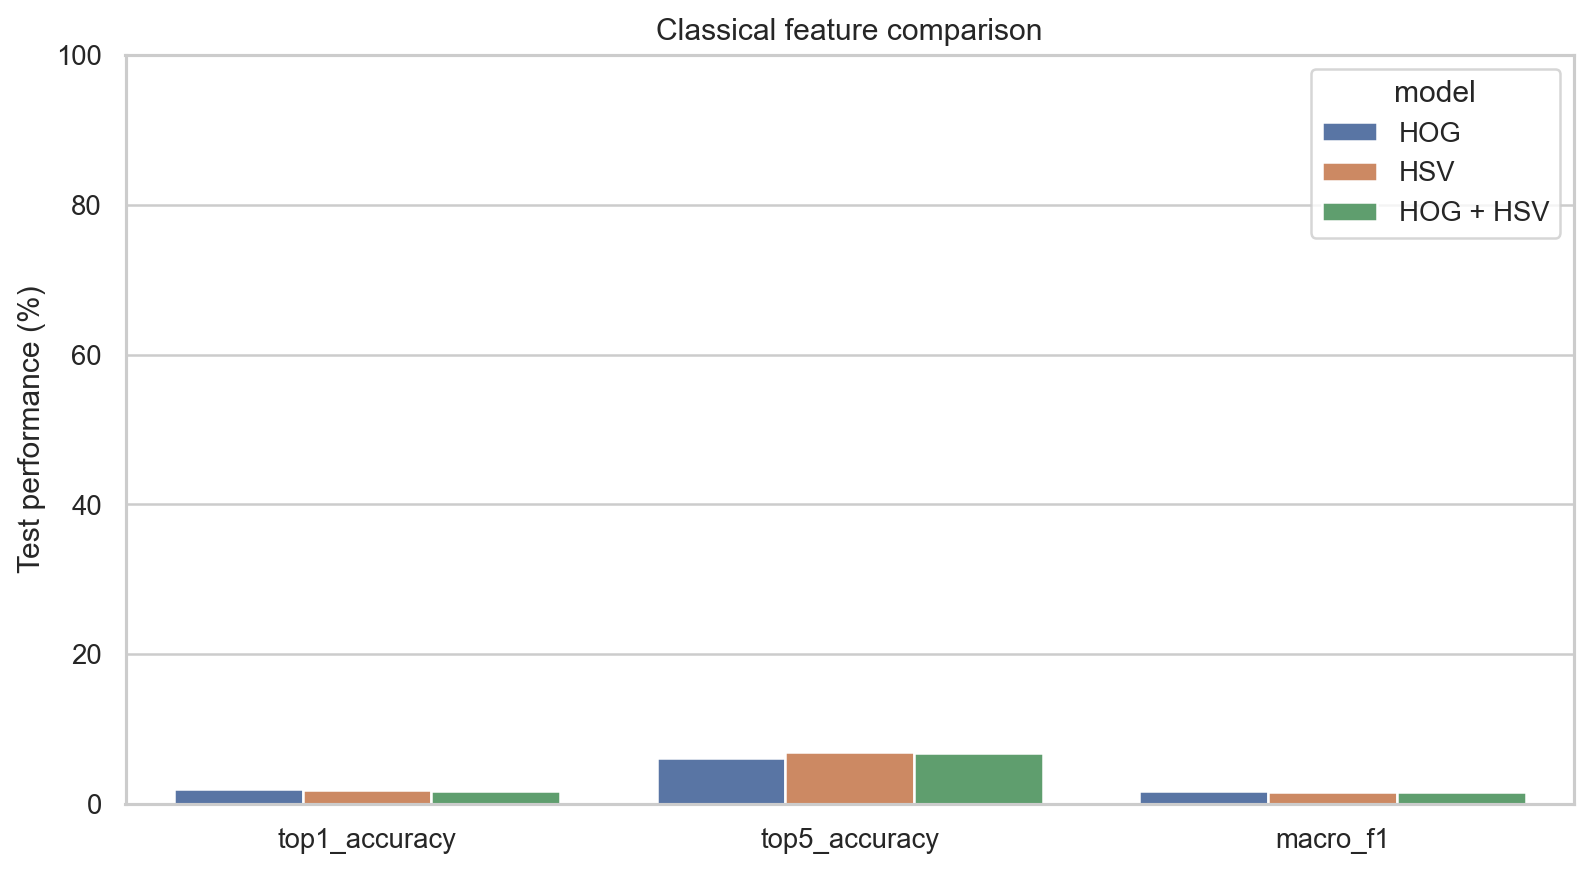

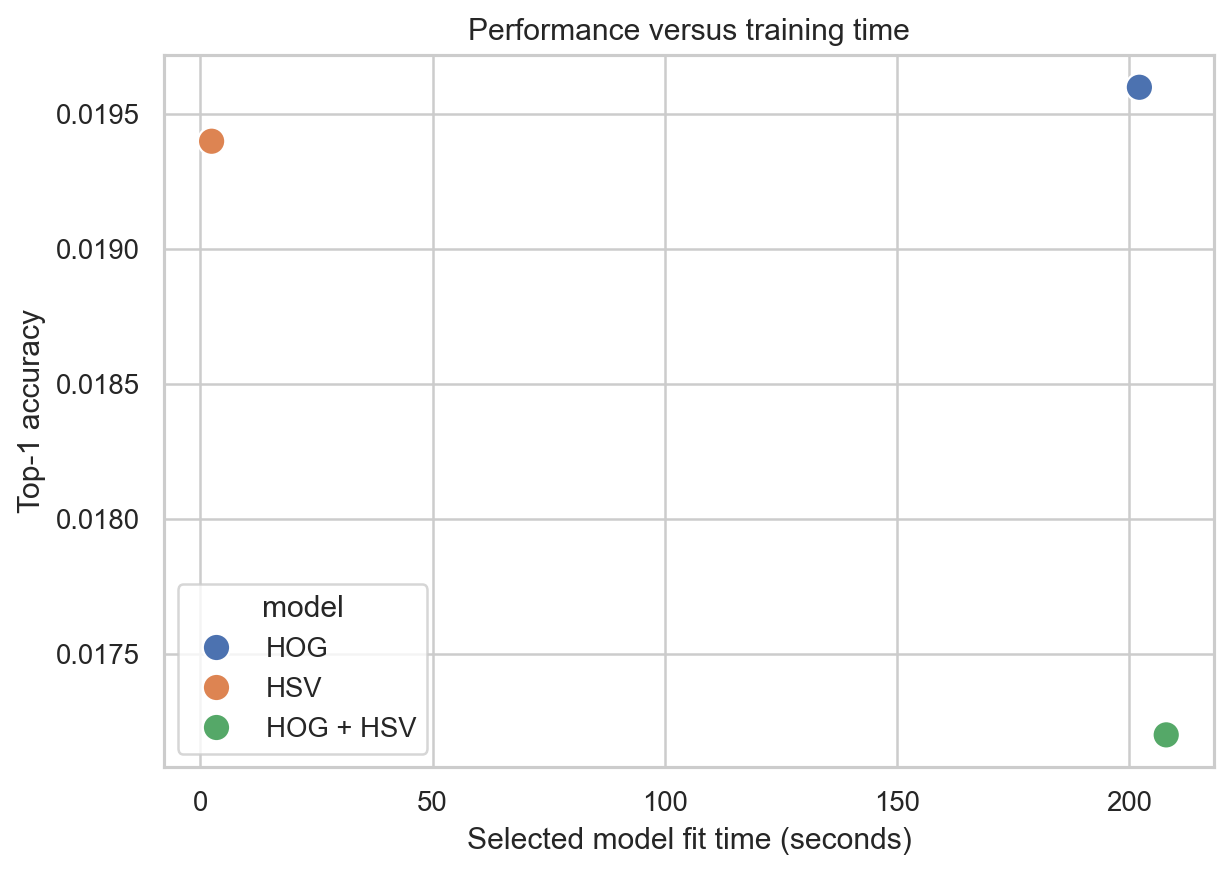

In [17]:
metric_columns = [
    "model",
    "top1_accuracy",
    "top5_accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "selected_C",
    "validation_macro_f1",
    "feature_dimension",
    "selected_fit_seconds",
    "inference_seconds",
    "images_per_second",
]
display(summary[metric_columns].round(4).set_index("model"))
display(NotebookImage(filename=str(RESULT_ROOT / "comparison/test_metrics.png")))
display(NotebookImage(filename=str(RESULT_ROOT / "comparison/accuracy_vs_time.png")))

## Hyperparameter curves

The epoch bars above show optimisation progress for each SGD model. For model selection, the figures below compare training/validation multiclass hinge loss, macro-F1 and runtime across candidate `C` values.

### HOG

,C,fit_seconds,validation_seconds,training_accuracy,validation_accuracy,training_macro_f1,validation_macro_f1,training_hinge_loss,validation_hinge_loss
0,0.01,173.9548,0.2668,0.3594,0.0182,0.3736,0.0105,36.1043,98.7433
1,0.10,192.7854,0.2599,0.4687,0.0190,0.4926,0.0144,206.6613,763.2217
2,1.00,202.2270,0.2868,0.6754,0.0202,0.6895,0.0194,679.4098,5066.4038
3,10.00,199.4293,0.2552,0.9639,0.0174,0.9641,0.0168,161.5293,23297.4121


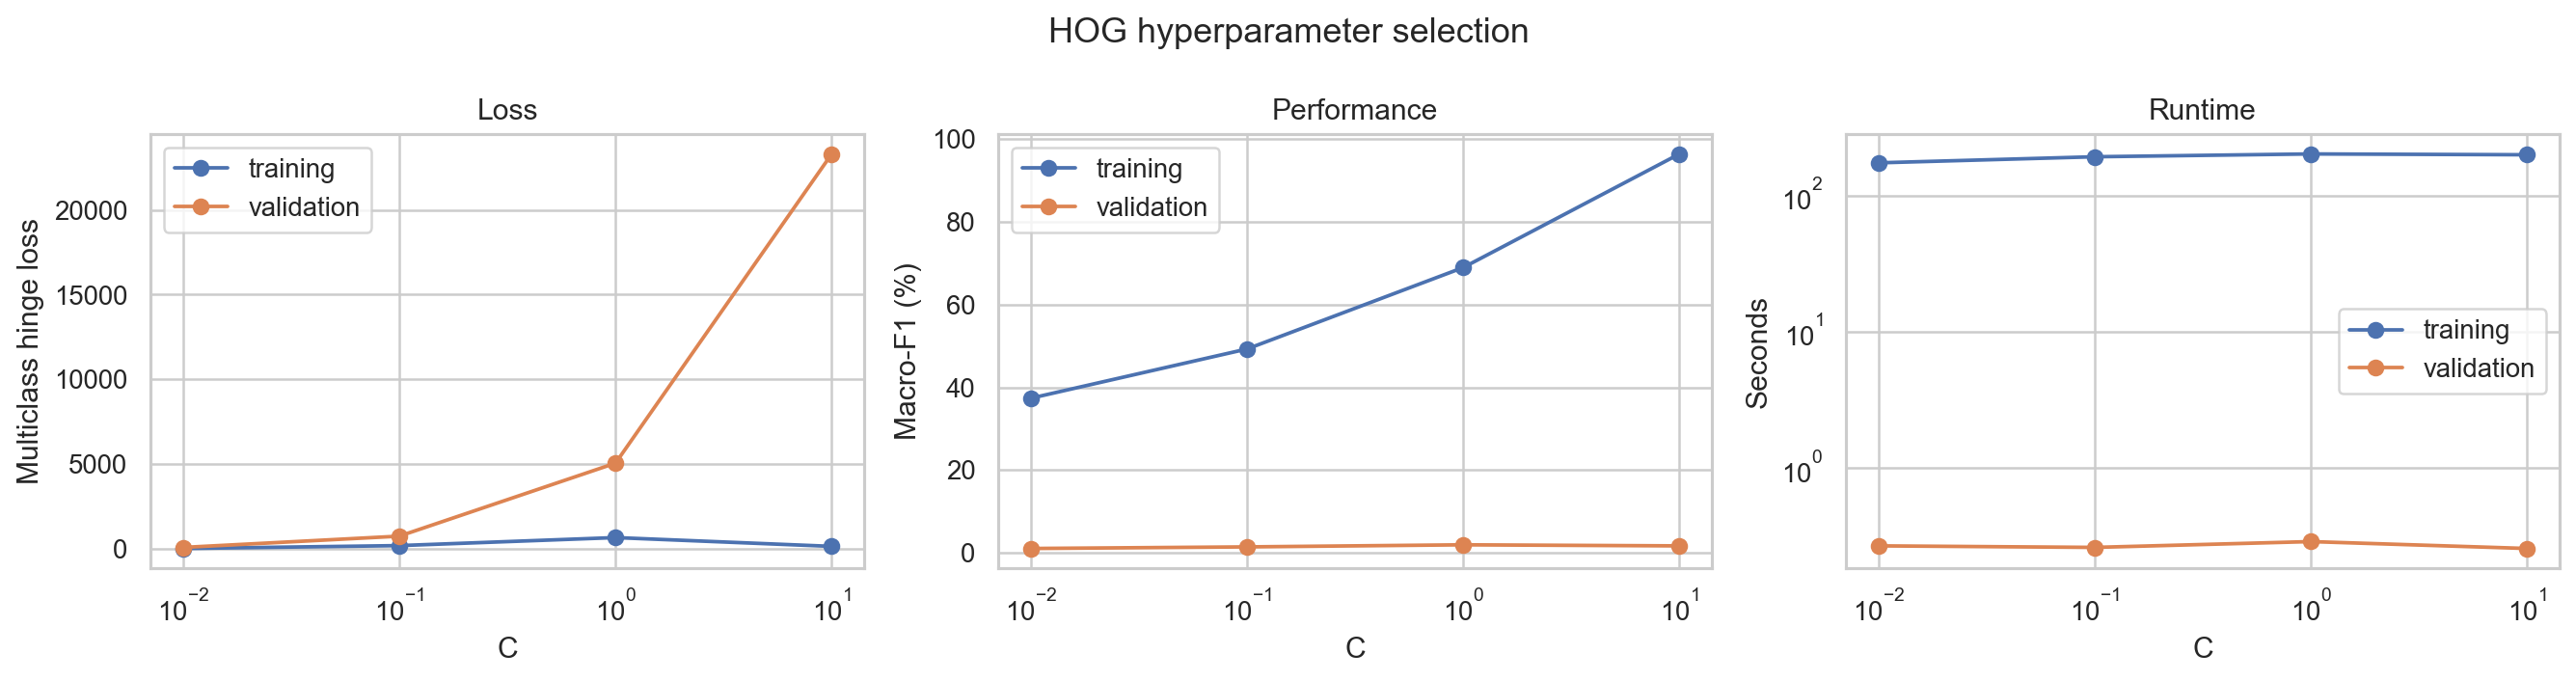

### HSV

,C,fit_seconds,validation_seconds,training_accuracy,validation_accuracy,training_macro_f1,validation_macro_f1,training_hinge_loss,validation_hinge_loss
0,0.01,2.6987,0.0109,0.0087,0.0070,0.0031,0.0016,17.3260,17.9772
1,0.10,2.6280,0.0099,0.0152,0.0098,0.0081,0.0039,70.5702,75.8651
2,1.00,2.7518,0.0084,0.0342,0.0190,0.0263,0.0106,180.5209,219.0841
3,10.00,2.4215,0.0080,0.0424,0.0214,0.0384,0.0177,405.8354,547.2426


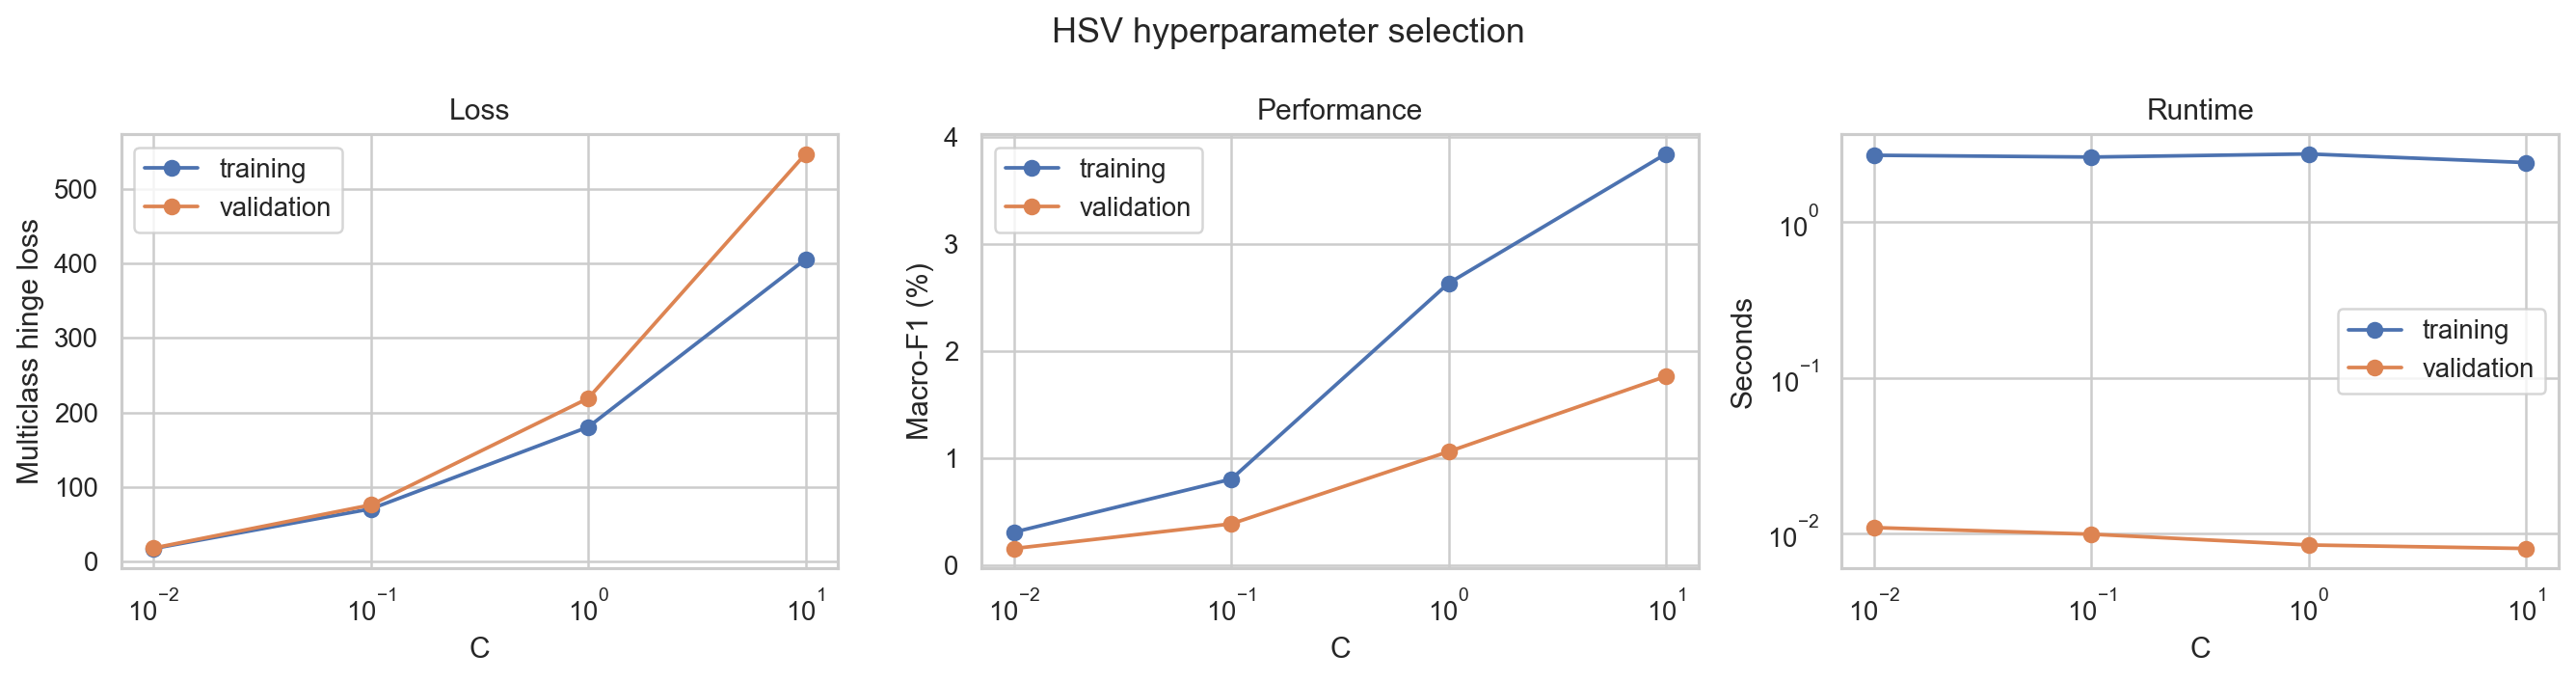

### HOG + HSV

,C,fit_seconds,validation_seconds,training_accuracy,validation_accuracy,training_macro_f1,validation_macro_f1,training_hinge_loss,validation_hinge_loss
0,0.01,205.4449,0.2675,0.3614,0.0224,0.3826,0.0146,36.5434,99.1573
1,0.10,224.3972,0.2876,0.4900,0.0192,0.5148,0.0138,199.7118,753.9213
2,1.00,205.5457,0.3352,0.6924,0.0206,0.7056,0.0191,625.4348,4942.8472
3,10.00,208.0050,0.5100,0.9694,0.0226,0.9696,0.0221,135.1194,22795.7188


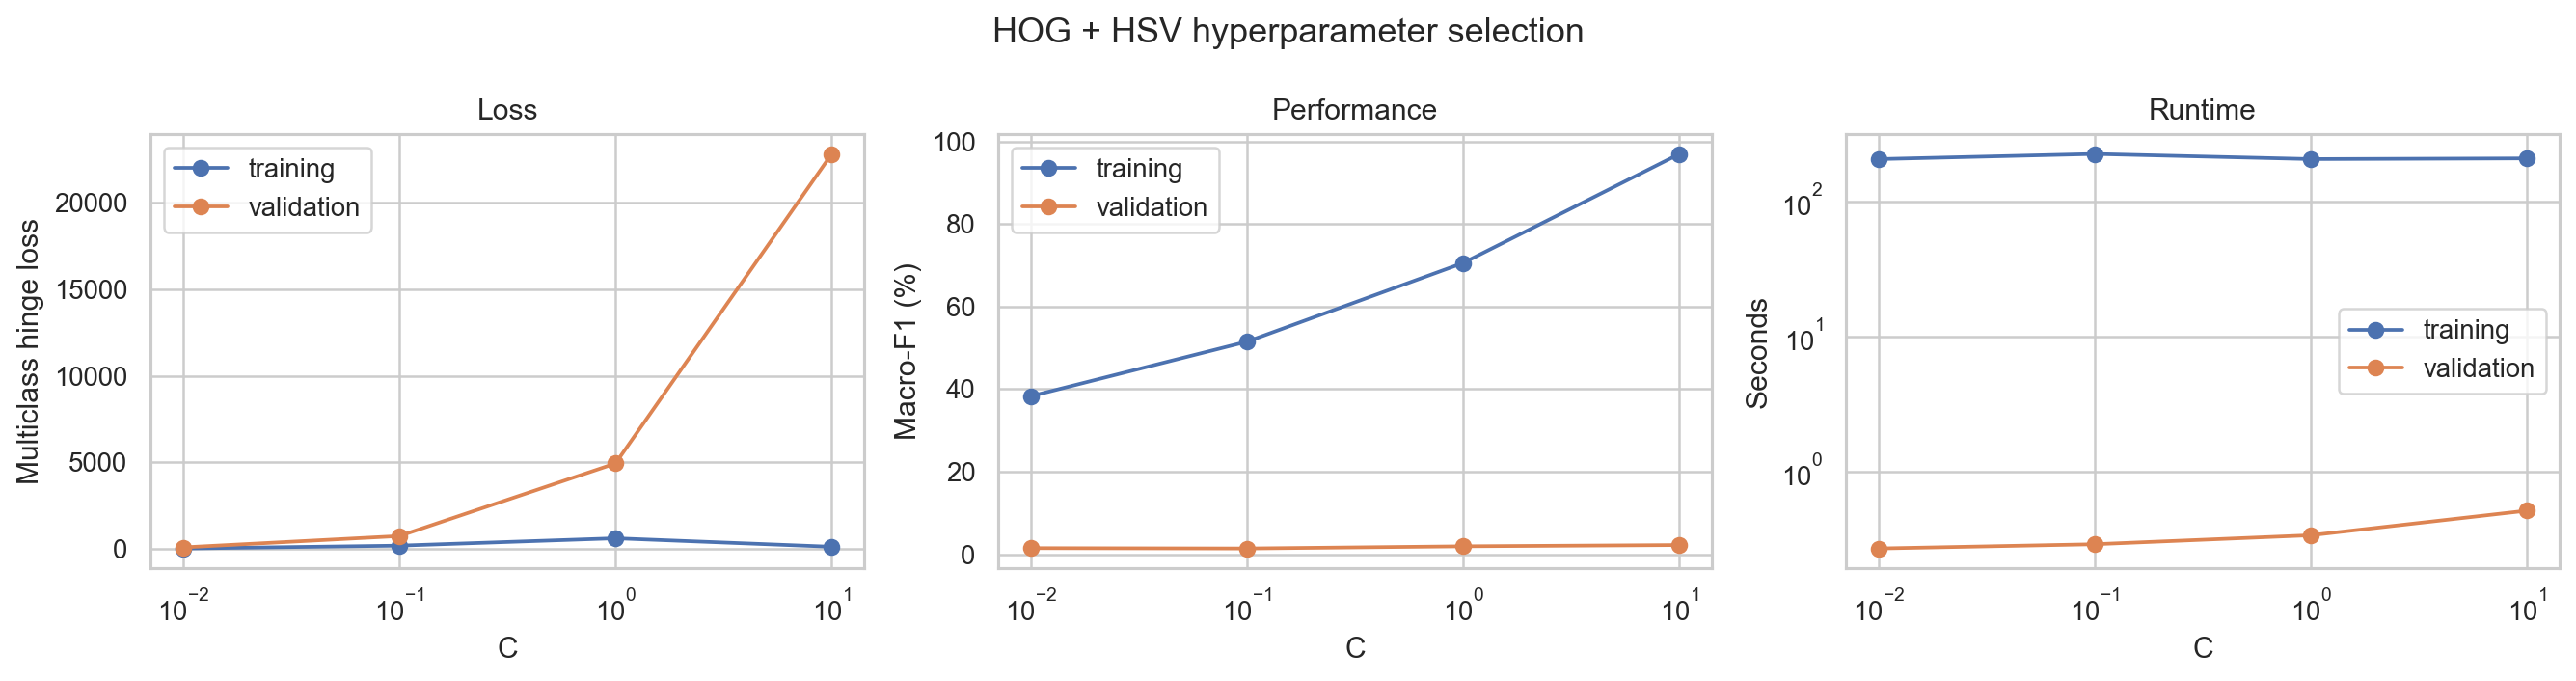

In [18]:
for feature_name in config["features"]["names"]:
    display(Markdown(f"### {DISPLAY_NAMES[feature_name]}"))
    tuning = pd.read_csv(RESULT_ROOT / feature_name / "tuning_history.csv")
    display(tuning.round(4))
    display(NotebookImage(filename=str(RESULT_ROOT / feature_name / "figures/tuning.png")))

## Confusion matrices and most confused species

### HOG

,true_species,predicted_species,count
0,Panurus biarmicus,Typha angustifolia,4
1,Veronica teucrium,Matricaria discoidea,3
2,Helicoverpa armigera,Polites sabuleti,3
3,Melipotis jucunda,Acronicta vinnula,3
4,Ceanothus thyrsiflorus,Matricaria discoidea,3
5,Spatula discors,Tachybaptus ruficollis,2
6,Rhus microphylla,Lupinus truncatus,2
7,Tringa semipalmata,Vanellus armatus,2
8,Campanula sibirica,Matricaria discoidea,2
9,Zale horrida,Lomographa glomeraria,2


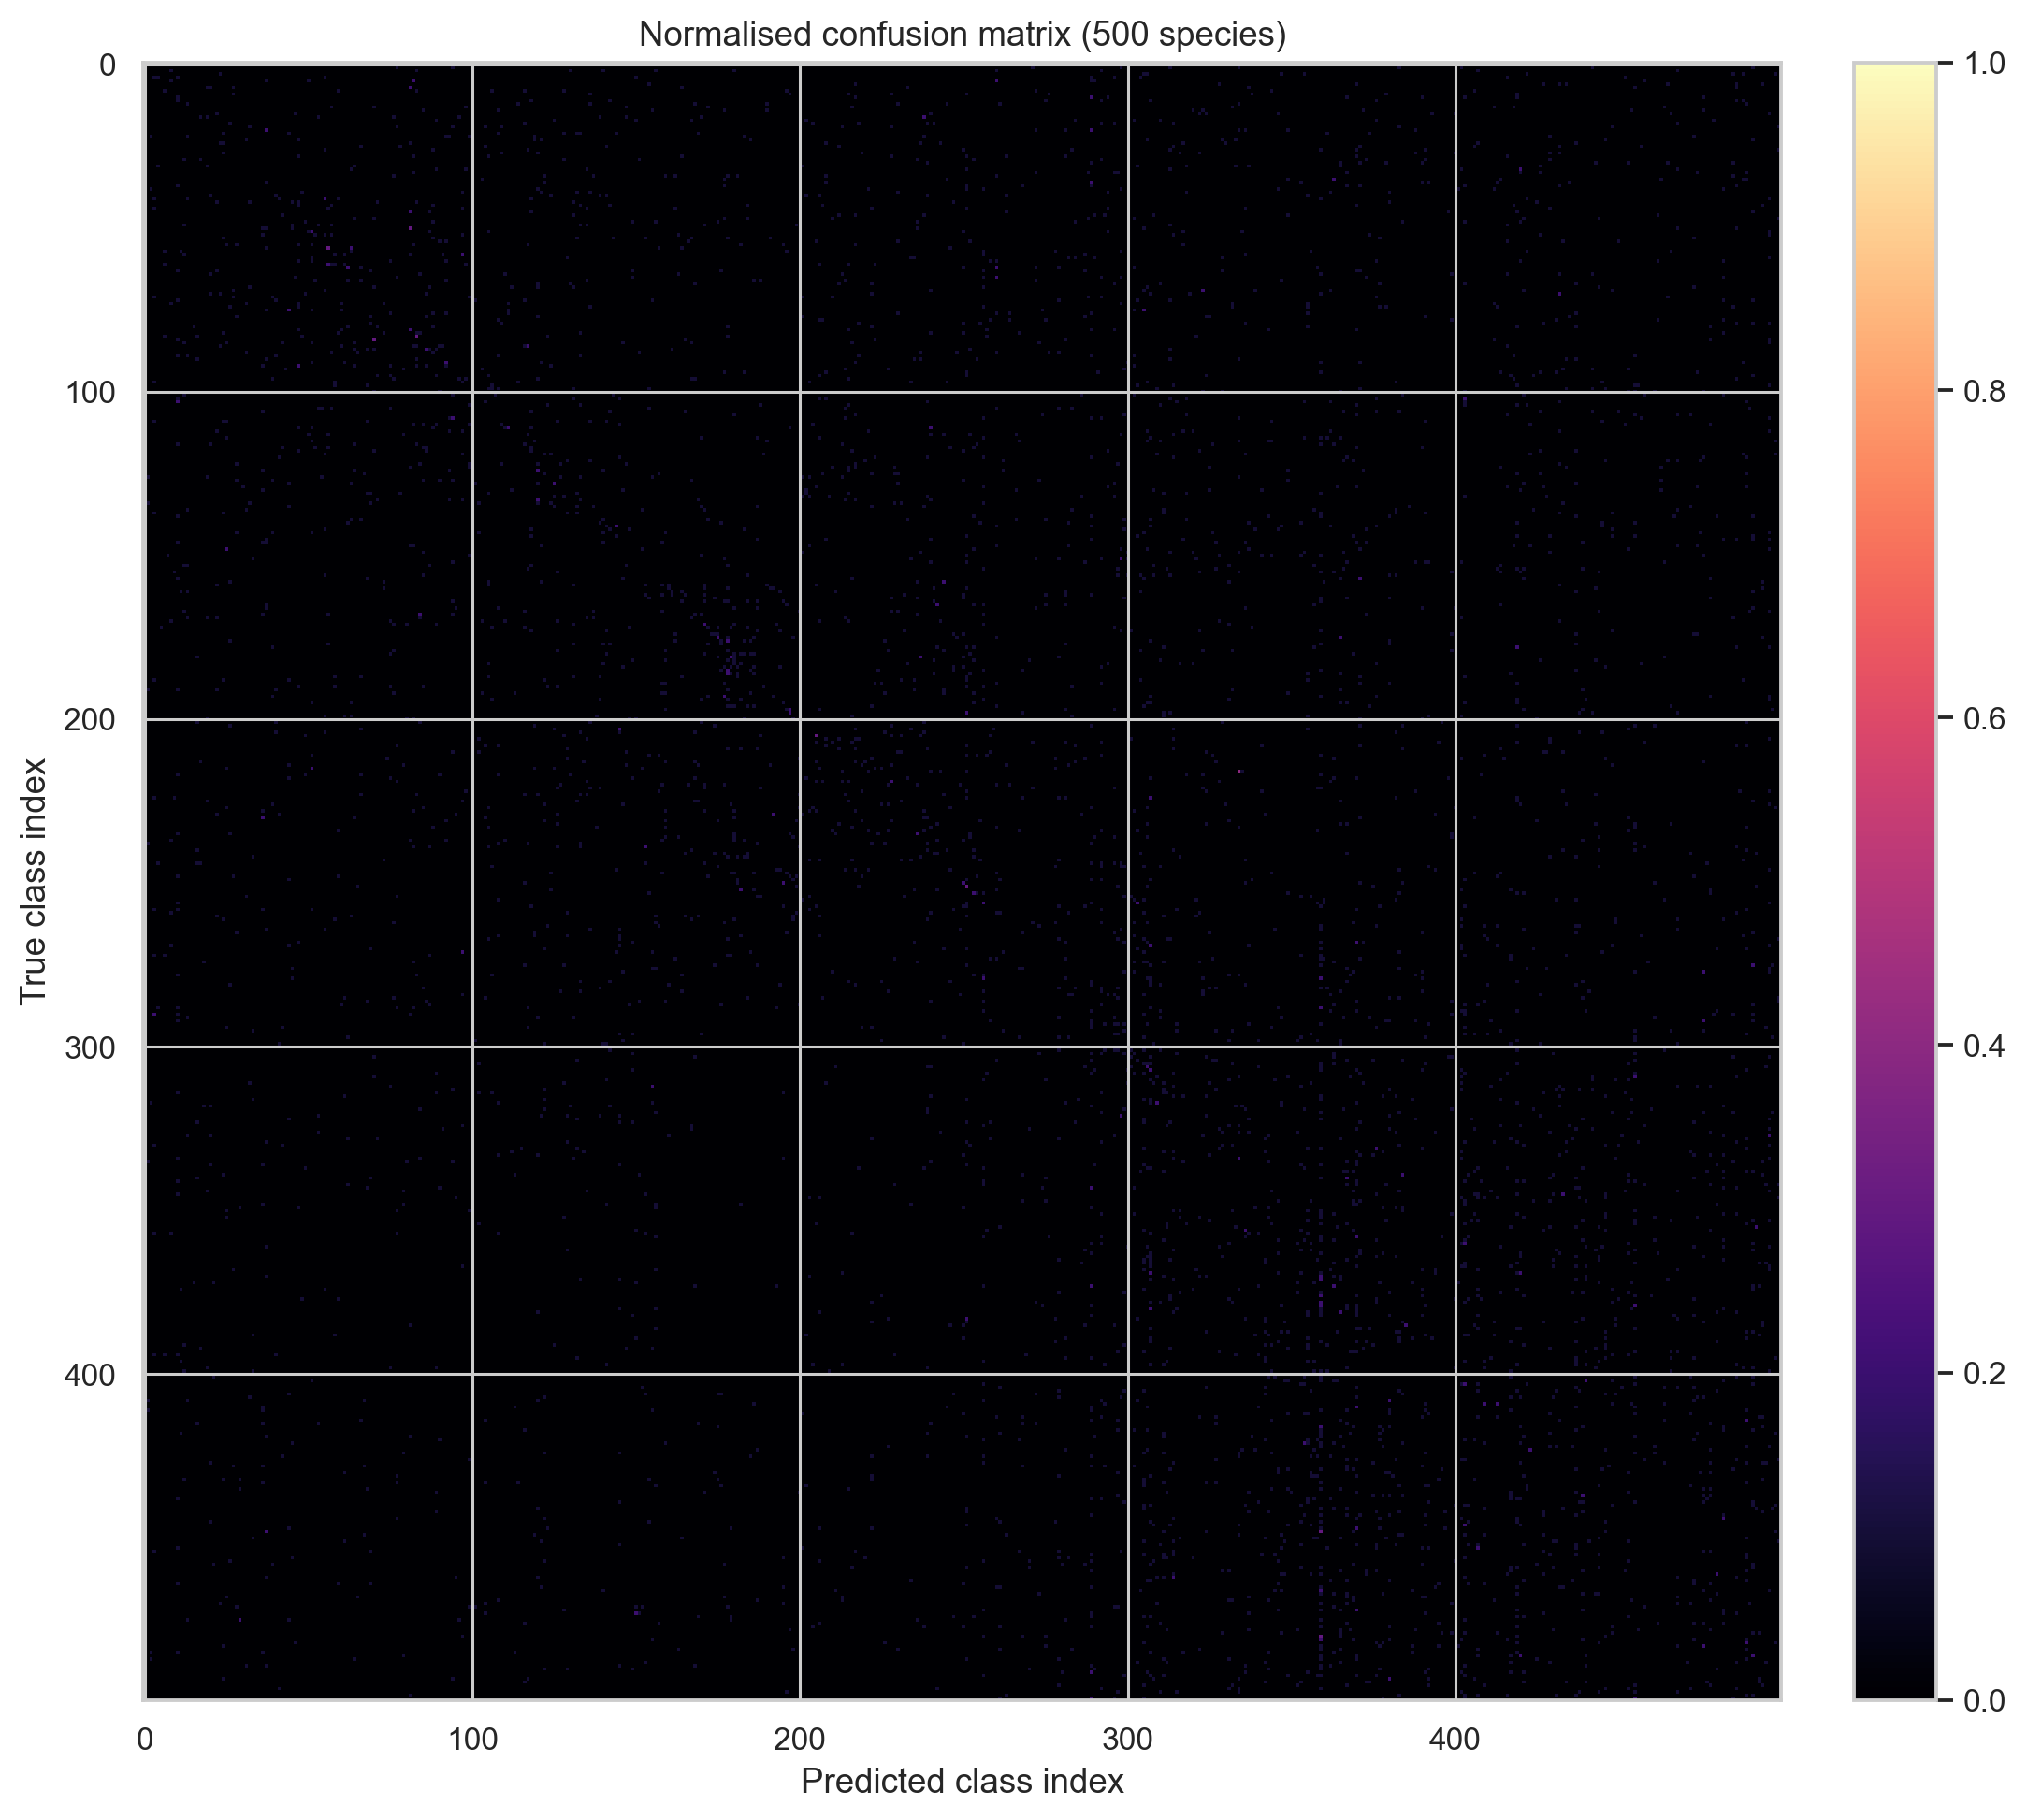

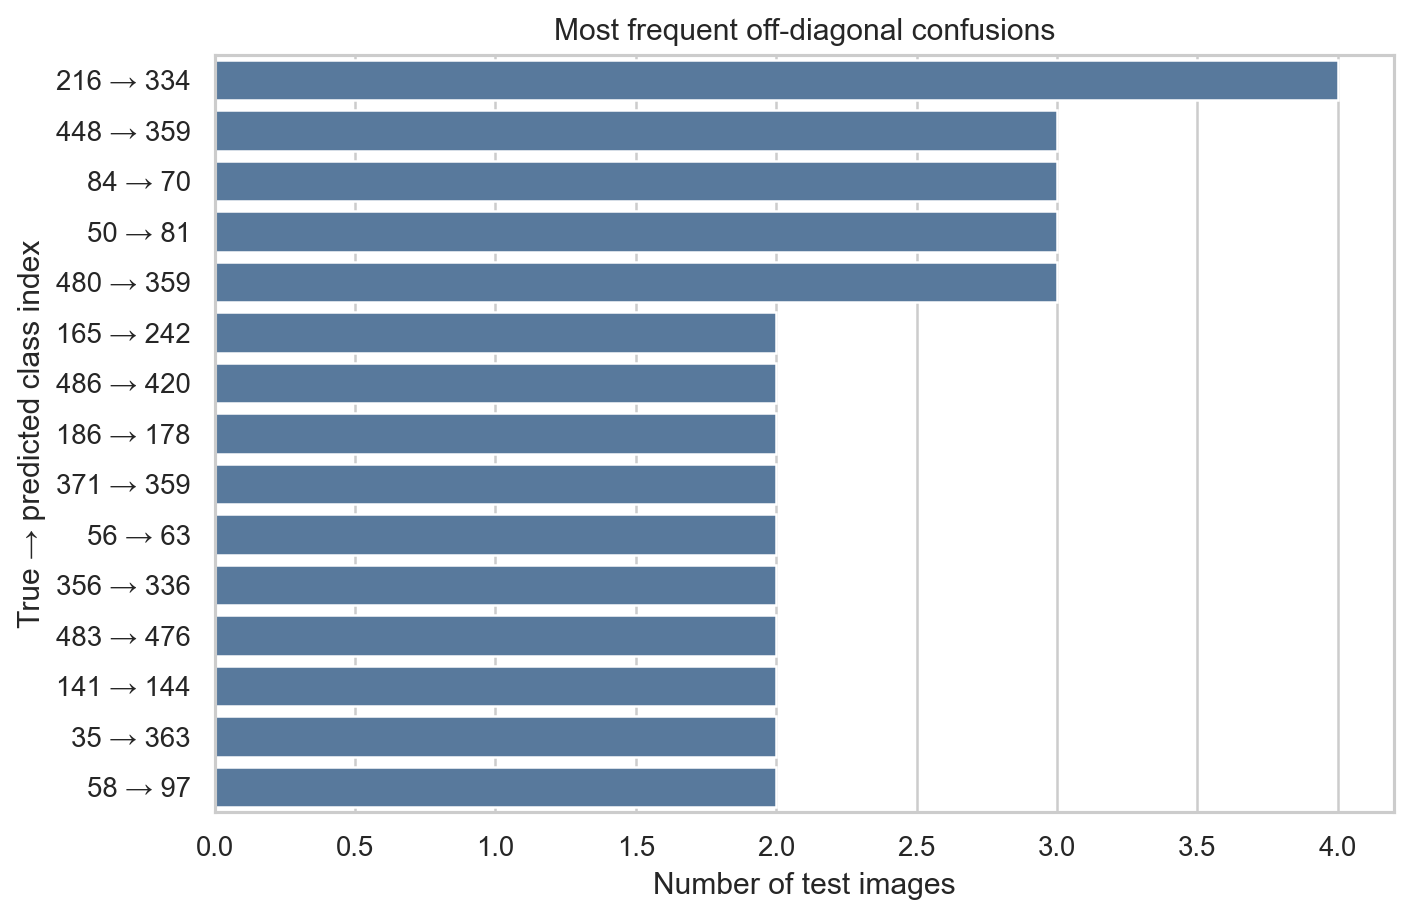

### HSV

,true_species,predicted_species,count
0,Phocarctos hookeri,Pellaea glabella,5
1,Pelecanus thagus,Pellaea glabella,5
2,Semibalanus balanoides,Pellaea glabella,5
3,Alnus rhombifolia,Pellaea glabella,5
4,Quercus kelloggii,Pellaea glabella,5
5,Phlyctis argena,Pellaea glabella,5
6,Tradescantia fluminensis,Ampelopsis cordata,5
7,Physalia physalis,Pellaea glabella,5
8,Cornus alba,Ampelopsis cordata,4
9,Empidonax flaviventris,Pellaea glabella,4


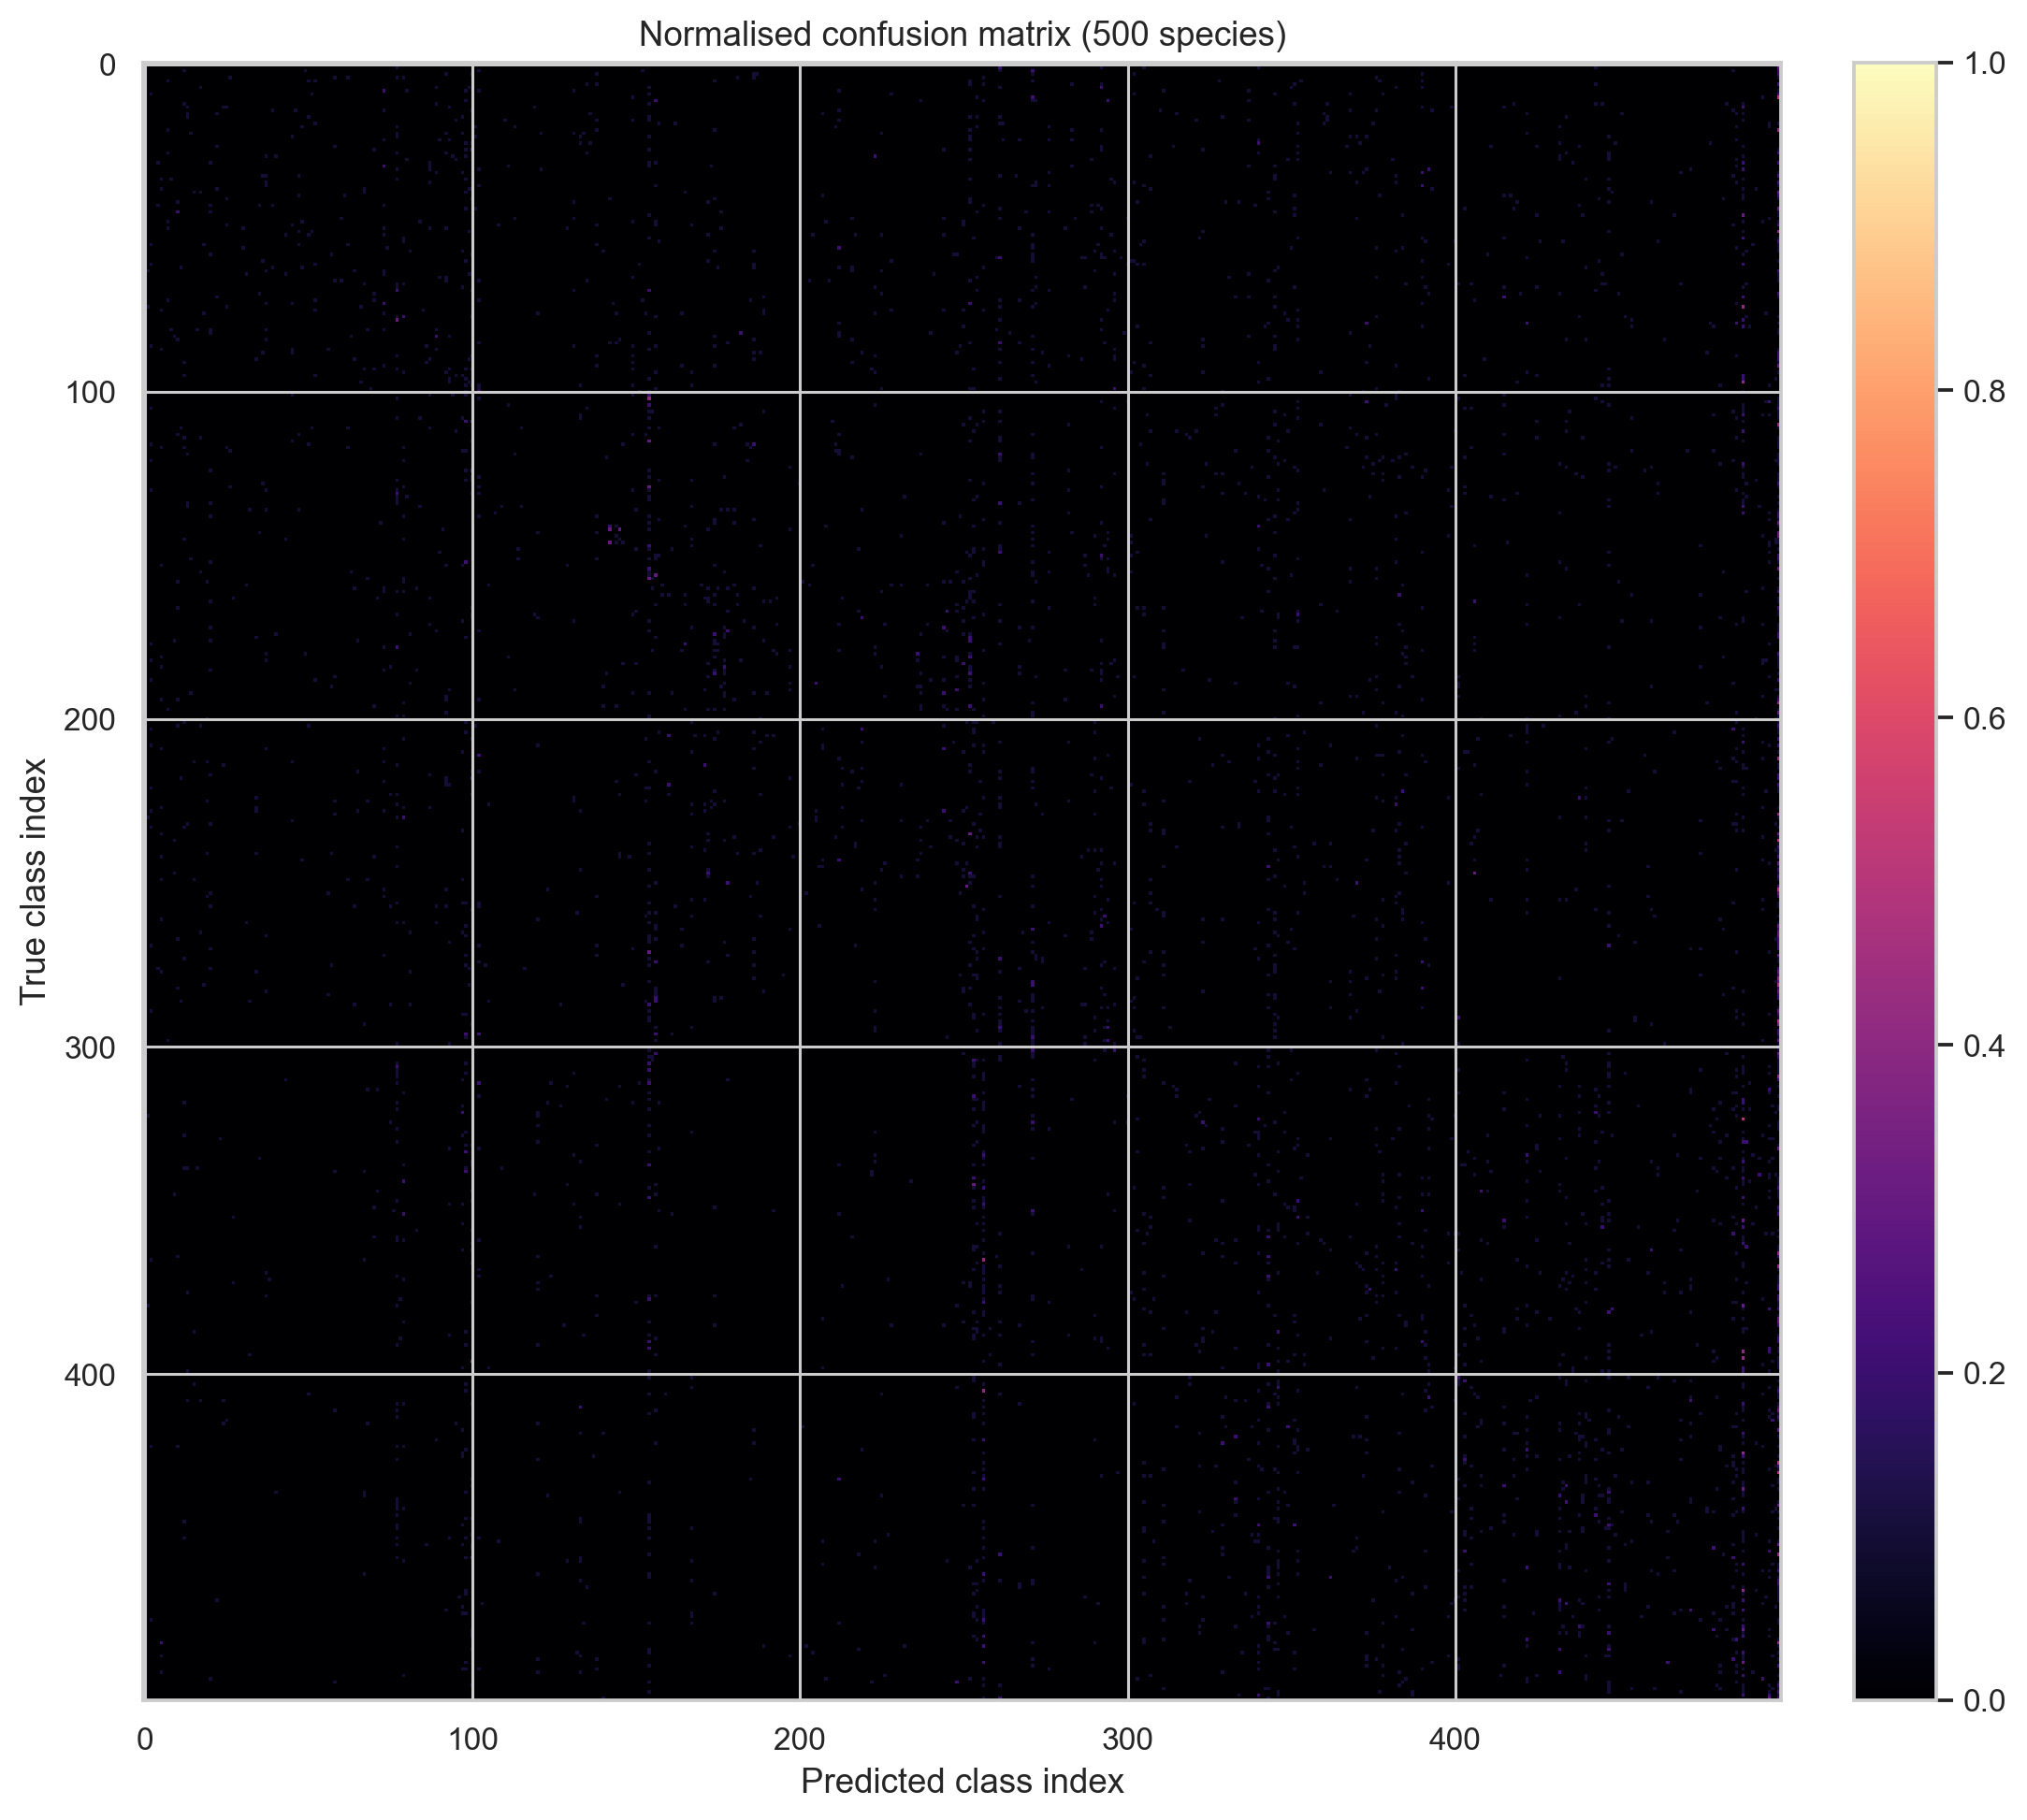

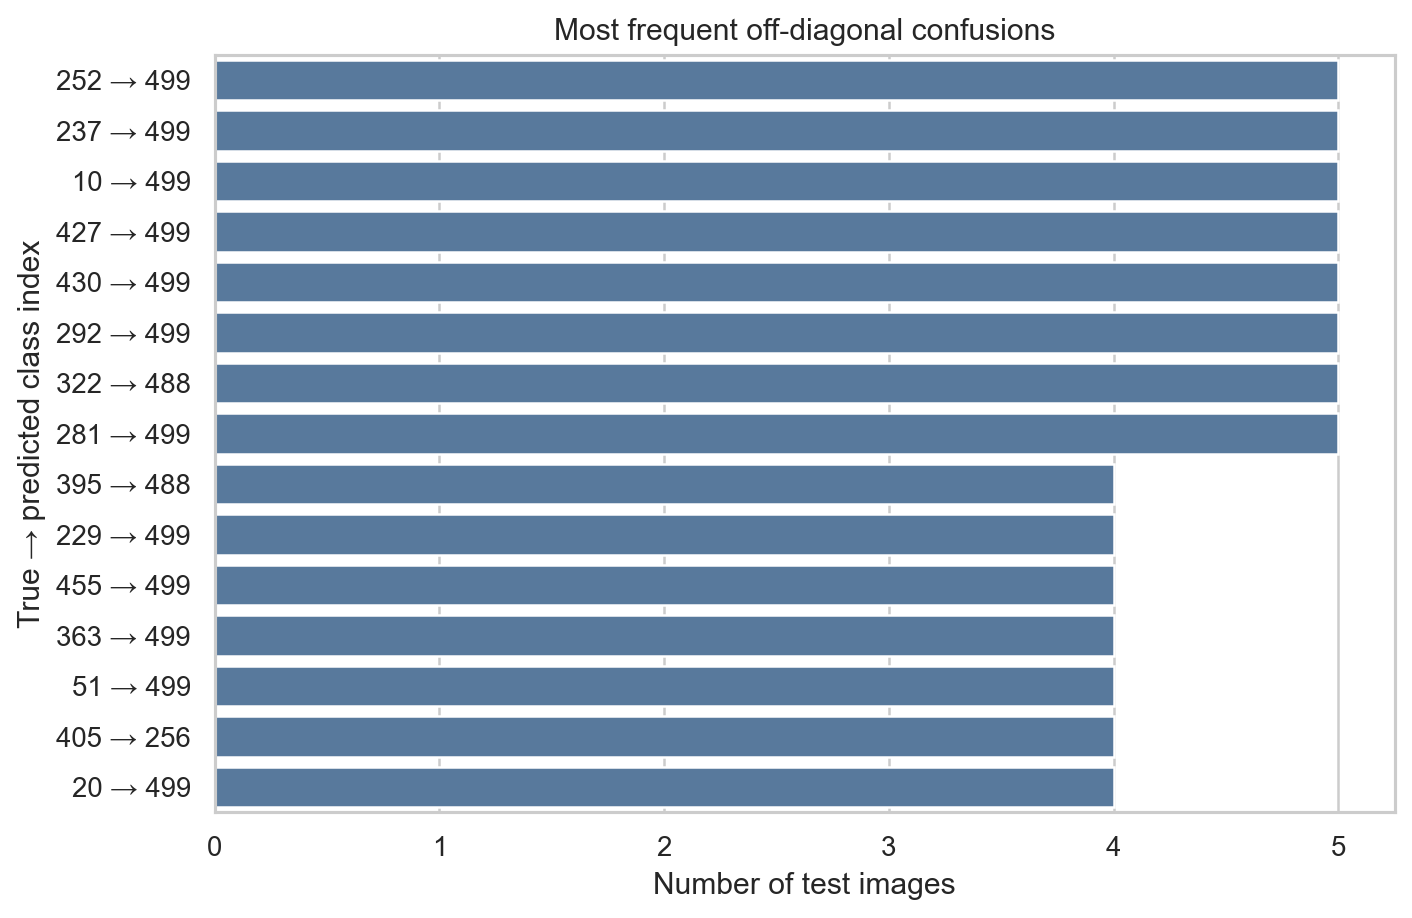

### HOG + HSV

,true_species,predicted_species,count
0,Stelgidopteryx ruficollis,Falco rupicolus,3
1,Palpita quadristigmalis,Virbia laeta,3
2,Castilleja indivisa,Pseudaspis cana,3
3,Arctostaphylos patula,Rhus microphylla,2
4,Pseudognaphalium obtusifolium,Phyllodoce empetriformis,2
5,Geniostoma ligustrifolium,Taraxia ovata,2
6,Coleonyx variegatus,Tachybaptus ruficollis,2
7,Diplacodes trivialis,Senecio vulgaris,2
8,Osteospermum moniliferum,Acanthocercus atricollis,2
9,Catocala neogama,Acronicta vinnula,2


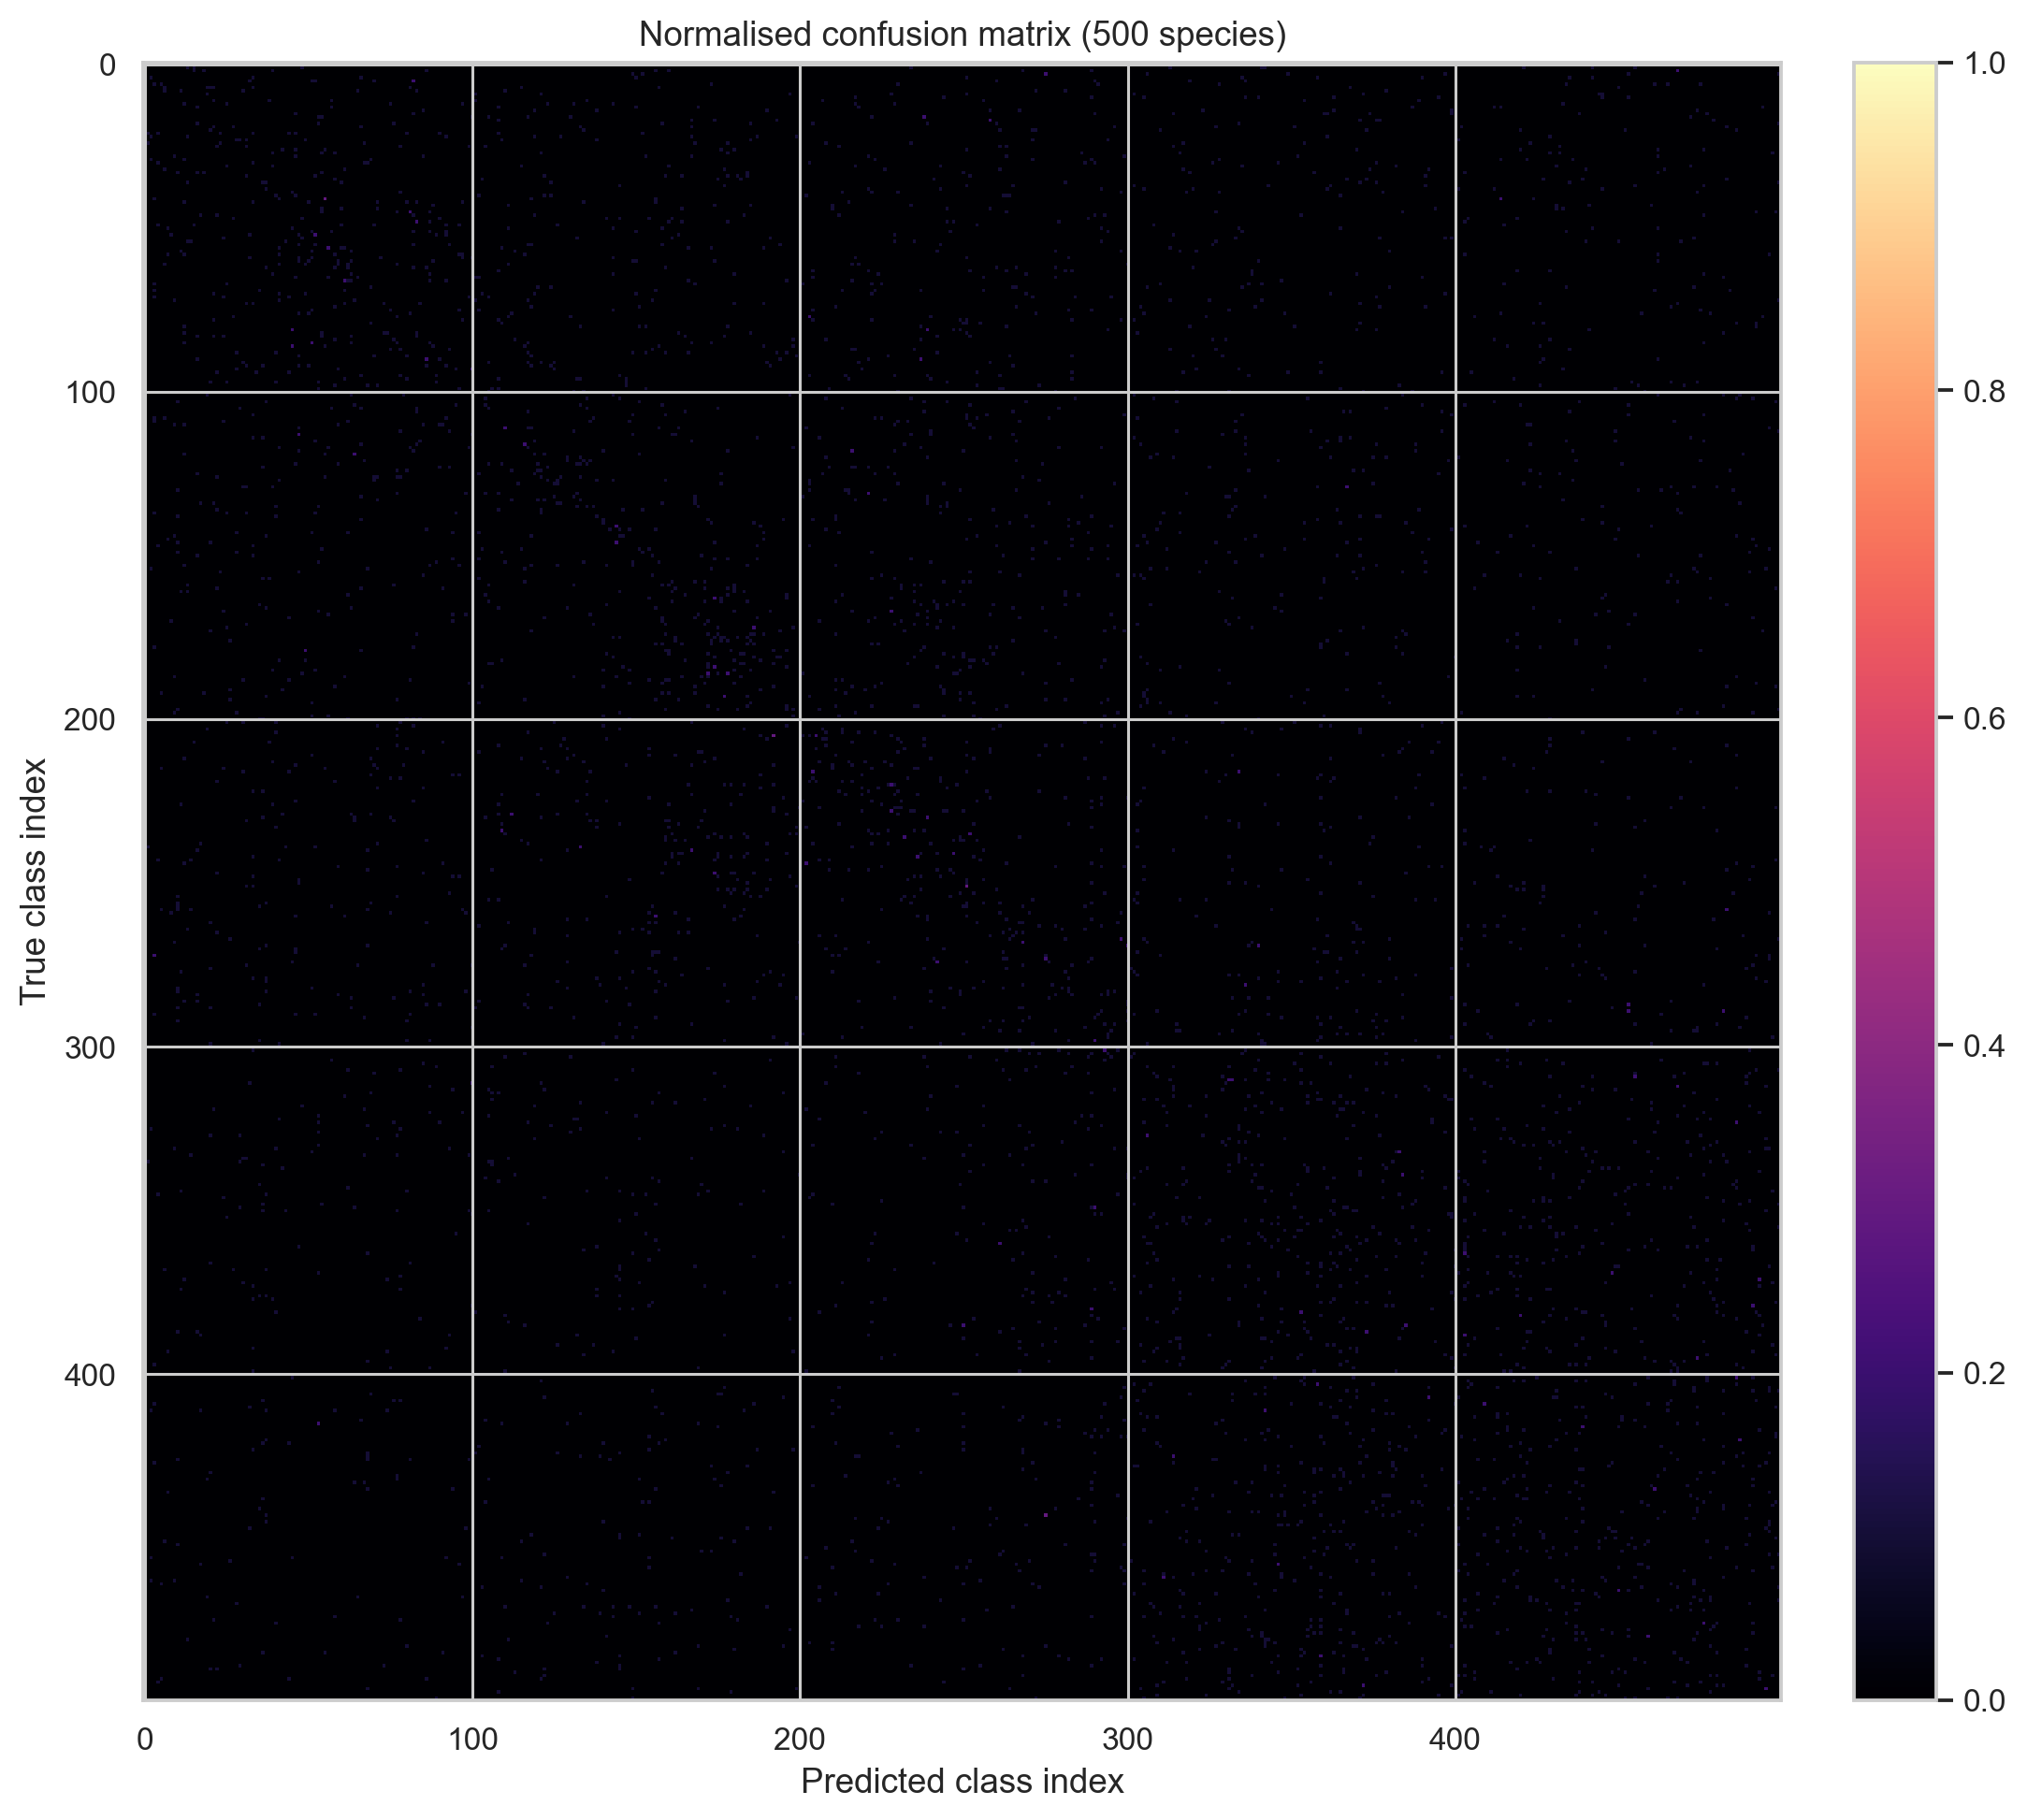

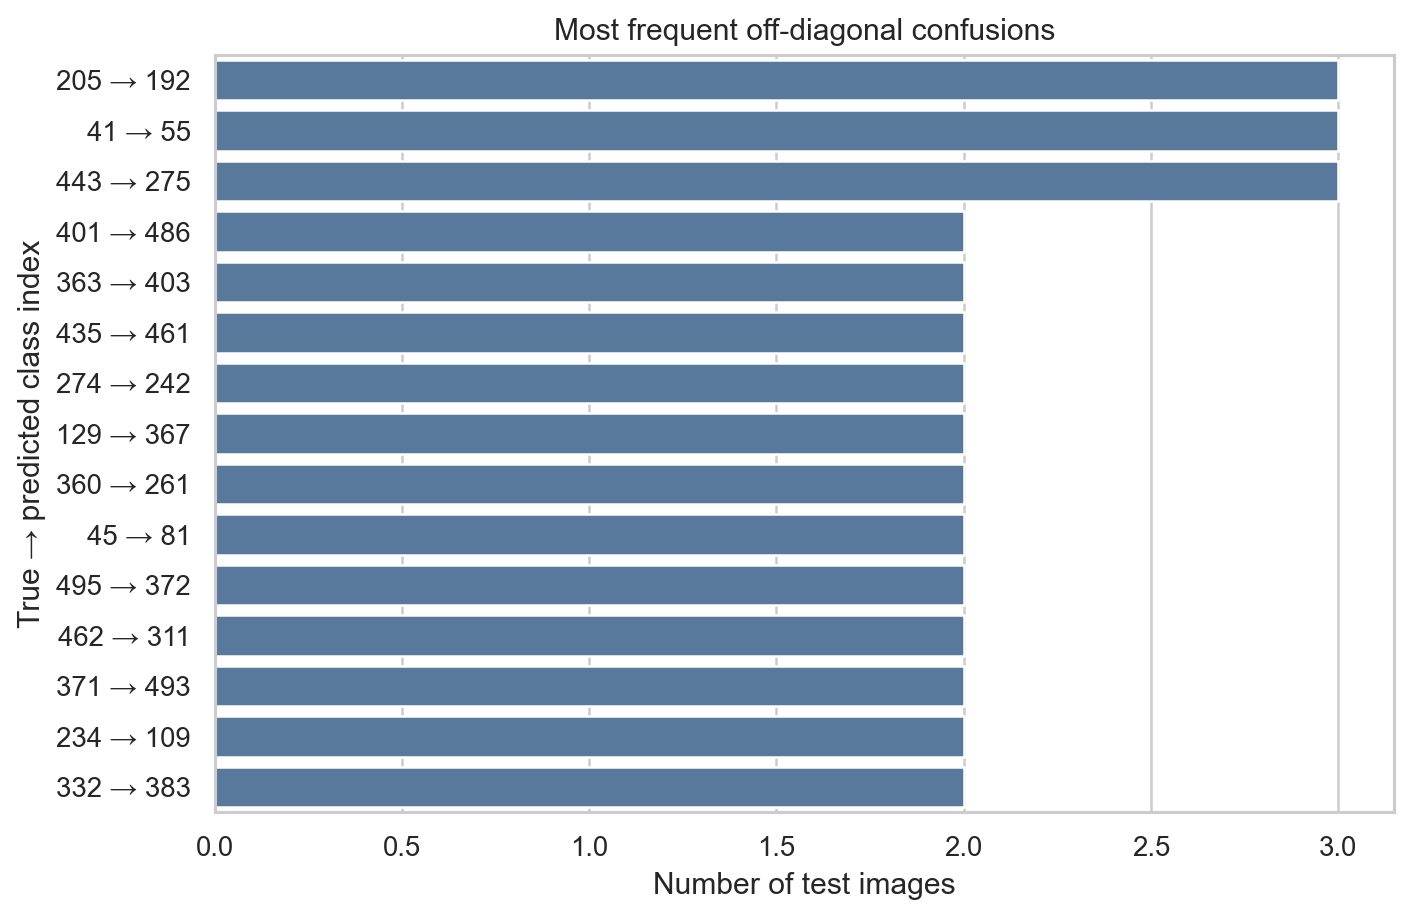

In [19]:
def species_name(class_name):
    return " ".join(str(class_name).split("_")[-2:])

for feature_name in config["features"]["names"]:
    experiment_root = RESULT_ROOT / feature_name
    pairs = pd.read_csv(experiment_root / "confused_pairs.csv").head(15)
    pairs["true_species"] = pairs["true_class"].map(species_name)
    pairs["predicted_species"] = pairs["predicted_class"].map(species_name)
    display(Markdown(f"### {DISPLAY_NAMES[feature_name]}"))
    display(pairs[["true_species", "predicted_species", "count"]])
    display(NotebookImage(filename=str(experiment_root / "figures/confusion_matrix.png")))
    display(NotebookImage(filename=str(experiment_root / "figures/confused_pairs.png")))

In [20]:
runtime = {
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "scikit_learn_version": sklearn.__version__,
    "scikit_image_version": skimage.__version__,
}
with (RESULT_ROOT / "runtime.json").open("w", encoding="utf-8") as handle:
    json.dump(runtime, handle, indent=2)
runtime

{'python_version': '3.10.11',
 'platform': 'macOS-26.5.1-arm64-arm-64bit',
 'scikit_learn_version': '1.7.2',
 'scikit_image_version': '0.25.2'}

## Interpretation checklist

When writing the report, compare whether shape (HOG), colour (HSV), or their combination works best; identify the selected `C`; discuss the accuracy/runtime trade-off; inspect whether combining features consistently improves per-class recognition; and compare all classical baselines with the scratch and pretrained ResNet-18 results. Do not use the held-out test metrics to retune `C`.